<a href="https://colab.research.google.com/github/rubengamarro/practicas_aprendizaje_no_supervisado/blob/main/3_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#EJERCICIO 1

In [243]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torchvision
from torchvision import transforms

**Apartado a**

In [244]:
cifar_dataset = torchvision.datasets.CIFAR10(root="./", train=True, download=True)

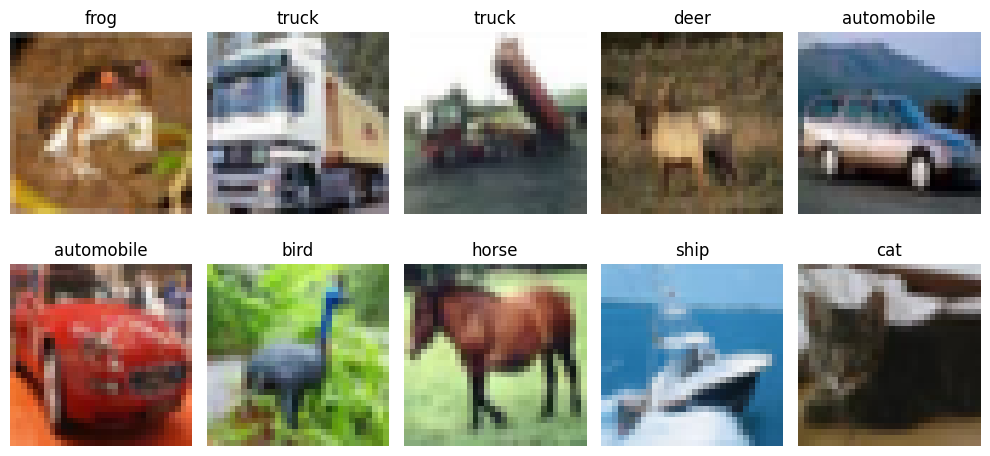

In [245]:
import matplotlib.pyplot as plt

#Definimos las clases del dataset para utilizarlas de etiqueta
clases = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

#Dibujamos las 10 primeras junto con su salida deseada
plt.figure(figsize=(10, 5))
for i in range(10):
    image, label = cifar_dataset[i]
    plt.subplot(2, 5, i+1)
    plt.imshow(image)
    plt.title(clases[label])
    plt.axis('off')
plt.tight_layout()
plt.show()

**Apartado b**

In [246]:
lista_muestras = [torchvision.transforms.ToTensor()(img) for img, _ in cifar_dataset]
lista_etiquetas = [label for _, label in cifar_dataset]

print(f"Cantidad de imágenes extraídas: {len(lista_muestras)}")
print(f"Cantidad de etiquetas extraídas: {len(lista_etiquetas)}")

Cantidad de imágenes extraídas: 50000
Cantidad de etiquetas extraídas: 50000


**Apartado c**

In [247]:
from torch.utils.data import DataLoader, Dataset, TensorDataset
import numpy as np
from PIL import Image

In [248]:
class CIFAR10Personalizado(Dataset):
    def __init__(self, muestras, etiquetas, transform=None):
        self.muestras = muestras
        self.etiquetas = etiquetas
        self.transform = transform

    def __len__(self):
        return len(self.muestras)

    def __getitem__(self, idx):
        image = self.muestras[idx]
        label = self.etiquetas[idx]

        #Convertimos a imagen si es un array o un tensor
        if isinstance(image, np.ndarray):
            image = Image.fromarray(image)
        elif isinstance(image, torch.Tensor):
            if image.ndim == 3 and image.shape[0] in [1, 3]:
                 image = image.permute(1, 2, 0).numpy()
                 image = Image.fromarray(image.astype(np.uint8))
            else:
                 pass

        if self.transform:
            image = self.transform(image)

        return image, label

In [249]:
#Definimos el transformador
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

#Creamos una instancia del dataset personalizado
dataset_personalizado = CIFAR10Personalizado(lista_muestras, lista_etiquetas, transform=transform)

**Apartado d**

In [250]:
# Obtenemos una muestra transformada
imagen_transformada, _ = dataset_personalizado[0]

# Imprimimos el tamaño de la muestra transformada
print(f"Tamaño de una muestra después de la transformación: {imagen_transformada.shape}")

Tamaño de una muestra después de la transformación: torch.Size([3, 64, 64])


**Apartado e**

In [251]:
data_loader = DataLoader(dataset_personalizado, batch_size=10, shuffle=True)
num_epocas = 3
for epoca in range(num_epocas):
    print(f'Época {epoca + 1}')
    for i, (images, labels) in enumerate(data_loader):
      if i % 1000 == 0:
            print(f'Lote {i}:', 'Salidas_deseadas =', labels)

Época 1
Lote 0: Salidas_deseadas = tensor([0, 2, 2, 0, 3, 8, 5, 9, 4, 0])
Lote 1000: Salidas_deseadas = tensor([2, 3, 6, 1, 6, 5, 9, 7, 7, 4])
Lote 2000: Salidas_deseadas = tensor([0, 2, 3, 1, 1, 9, 5, 4, 3, 5])
Lote 3000: Salidas_deseadas = tensor([1, 2, 8, 9, 4, 1, 6, 2, 2, 4])
Lote 4000: Salidas_deseadas = tensor([0, 0, 3, 2, 1, 0, 9, 8, 1, 0])
Época 2
Lote 0: Salidas_deseadas = tensor([4, 0, 4, 5, 6, 0, 5, 1, 7, 3])
Lote 1000: Salidas_deseadas = tensor([2, 8, 5, 5, 0, 5, 0, 8, 1, 4])
Lote 2000: Salidas_deseadas = tensor([7, 2, 9, 5, 0, 7, 2, 3, 8, 7])
Lote 3000: Salidas_deseadas = tensor([9, 2, 5, 7, 5, 6, 7, 1, 9, 2])
Lote 4000: Salidas_deseadas = tensor([9, 6, 0, 6, 9, 2, 7, 1, 7, 4])
Época 3
Lote 0: Salidas_deseadas = tensor([0, 5, 9, 4, 8, 6, 3, 0, 0, 5])
Lote 1000: Salidas_deseadas = tensor([1, 5, 0, 3, 3, 0, 5, 1, 9, 3])
Lote 2000: Salidas_deseadas = tensor([9, 5, 7, 1, 5, 3, 6, 4, 3, 1])
Lote 3000: Salidas_deseadas = tensor([8, 7, 8, 9, 5, 8, 7, 8, 9, 5])
Lote 4000: Salidas_

#EJERCICIO 2

**Apartado a**

In [252]:
transformacion = transforms.Compose([transforms.ToTensor()])

In [253]:
ent_dataset = torchvision.datasets.FashionMNIST(root="./", train=True, transform=transformacion, download=True)

val_dataset = torchvision.datasets.FashionMNIST(root="./", train=False, transform= transformacion, download=True)

assert isinstance(ent_dataset, torch.utils.data.Dataset)  # Verifica que sea un conjunto de datos

**Apartado b**

In [254]:
# Definimos el tamaño del lote
tam_lote = 64
torch.manual_seed(1)  # Semilla para reproducibilidad

# Preparamos los datos de validación directamente:
# Normalizamos las imágenes a [0, 1]
X_val = val_dataset.data.float() / 255.
y_val = val_dataset.targets

ent_moon_dataset = TensorDataset(X_val, y_val)

ent_loader = DataLoader(ent_dataset, tam_lote, shuffle=True)
val_loader = DataLoader(val_dataset, tam_lote, shuffle=False)
ent_moon_dl = DataLoader(ent_moon_dataset, tam_lote, shuffle=True)

**Apartado c**

In [255]:
torch.manual_seed(10)

modelo = nn.Sequential(
    ### 1ª Capa de oculta (entrada) ###
    nn.Flatten(),  # Aplanamos la imagen
    nn.Linear(784, 128),  # Usamos 784 rasgos de entrada y 128 neuronas
    nn.Sigmoid(),

    ### 2ª Capa oculta ###
    nn.Linear(128, 64),  # Usamos 64 neuronas
    nn.Sigmoid(),

    ### Capa de salida ###
    nn.Linear(64, 10),  # Usamos 10 neurona
    nn.Sigmoid()
)
modelo

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): Sigmoid()
  (3): Linear(in_features=128, out_features=64, bias=True)
  (4): Sigmoid()
  (5): Linear(in_features=64, out_features=10, bias=True)
  (6): Sigmoid()
)

**Apartado d**

In [256]:
import torch.nn.functional as F

def entrenar(modelo_red, num_epocas, ent_dataloader, X_valid, y_valid,
             func_perdida, optimizador, clasificacion=False):
  """
  Parámetros:
    ----------
    modelo_red : torch.nn.Module
        El modelo de red neuronal a entrenar.
    num_epocas : int
        Número de épocas para entrenar el modelo.
    ent_dataloader : torch.utils.data.DataLoader
        DataLoader que contiene los lotes del conjunto de entrenamiento.
    X_valid : torch.Tensor
        Tensor con las características del conjunto de validación.
    y_valid : torch.Tensor
        Tensor con las etiquetas del conjunto de validación (vector)
    loss_fn : callable
        Función de pérdida utilizada para calcular el error entre las predicciones y las etiquetas.
    optimizador : torch.optim.Optimizer
        Optimizador que actualiza los parámetros del modelo.
    clasificacion : bool, opcional (por defecto False)
        Si es True, calcula la exactitud además de la pérdida.

    Devuelve:
    -------
    loss_hist_ent : list[float]
        Lista con la pérdida promedio de entrenamiento por época.
    loss_hist_val : list[float]
        Lista con la pérdida promedio de validación por época.
    exact_hist_ent : list[float]
        Lista con la precisión promedio de entrenamiento por época (si clasificacion=True).
    exact_hist_val : list[float]
        Lista con la precisión promedio de validación por época (si clasificacion=True).
  """
  # Creamos listas para almacenar las métricas de entrenamiento y validación para cada época
  # 'loss' para la función de pérdida, 'exact' para la exactitud
  loss_hist_ent = [0] * num_epocas
  exact_hist_ent = [0] * num_epocas
  loss_hist_val = [0] * num_epocas
  exact_hist_val = [0] * num_epocas

  # Iniciamos el bucle de entrenamiento para todas las épocas
  for epoca in range(num_epocas):
    # Bucle a través de los lotes de entrenamiento (ent_dataloader)
    for x_lote, y_lote in ent_dataloader:
      # FORWARD #
      # Realizamos la predicción en el lote actual
      pred = modelo_red(x_lote)
      # Si la salida predicha es un vector  (una única neurona de salida)
      if (pred.size(1)==1):
        # Eliminamos la última dimensión (es equivalente y evitamos problemas sintácticos)
        pred = pred[:, 0]

      # Convert y_lote to one-hot encoding
      y_lote_one_hot = F.one_hot(y_lote, num_classes=10).float()

      # Calculamos la pérdida (loss) usando la función de pérdida especificada
      loss = func_perdida(pred, y_lote_one_hot)

      # BACKWARD
      loss.backward()
      optimizador.step()
      optimizador.zero_grad()

      # RENDIMIENTOS en entrenamiento
      # Acumulamos la pérdida media del entrenamiento para este lote
      loss_hist_ent[epoca] += loss.item()

      if clasificacion:
        if pred.dim()==1:  # 1 neurona => clasificación binaria
          if isinstance(func_perdida, nn.BCELoss): # Para BCELoss, con sigmoide explícita
            clase_pred = (pred >= 0.5).float()
          else:  # Para BCEWithLogitLoss, sin sigmoide explícita, la salida es un logit
            clase_pred = (pred >= 0.0).float()
        else:  # Varias neuronas de salida => clasificación múltiple
          clase_pred = torch.argmax(pred, dim=1)
        correcto = (clase_pred == y_lote).float()
        # Calculamos exactitud media de entrenamiento del lote
        exact_hist_ent[epoca] += correcto.mean().item()

    # Promediamos la pérdida y la precisión de entrenamiento para toda la
    # época dividiendo por el número de lotes
    loss_hist_ent[epoca] /= len(ent_dataloader)
    if clasificacion:
      exact_hist_ent[epoca] /= len(ent_dataloader)

    # RENDIMIENTOS en validación
    with torch.no_grad():
      pred = modelo_red(X_valid)
      if (pred.size(1)==1):
        pred = pred[:, 0]

      # Convert y_valid to one-hot encoding
      y_valid_one_hot = F.one_hot(y_valid, num_classes=10).float()

      loss = func_perdida(pred, y_valid_one_hot)

      # Almacenamos la pérdida media en validación
      loss_hist_val[epoca] = loss.item()
      # Si es un problema de clasificación => calculamos exactitudes
      if clasificacion:
        if pred.dim()==1: # Binaria
          if isinstance(func_perdida, nn.BCELoss): # Para BCELoss, con sigmoide explícita
            clase_pred = (pred >= 0.5).float()
          else:  # Para BCELossWithLogits, sin sigmoide explícita, la salida es un logit
            clase_pred = (pred >= 0.0).float()
        else:             # Multiclase
          clase_pred = torch.argmax(pred, dim=1)
        correcto = (clase_pred == y_valid).float()
        # Almacenamos la exactitud media en validación
        exact_hist_val[epoca] = correcto.mean().item()

    # Imprimir métricas cada cierto número de épocas (opcional)
    if (epoca + 1) % 10 == 0:
      print(f"Época {epoca + 1}/{num_epocas} | Pérdida Entrenamiento: {loss_hist_ent[epoca]:.4f} | "
            f"Pérdida Validación: {loss_hist_val[epoca]:.4f} | "
            f"Exactitud Entrenamiento: {exact_hist_ent[epoca]:.4f} | "
            f"Exactitud Validación: {exact_hist_val[epoca]:.4f}")

  # Retornamos las métricas de pérdida y precisión para el entrenamiento y la validación
  return loss_hist_ent, loss_hist_val, exact_hist_ent, exact_hist_val

In [257]:
# Definición de la función de pérdida y optimizador
loss_fn = nn.CrossEntropyLoss()
optimizador = torch.optim.SGD(modelo.parameters(), lr=0.01)

In [258]:
historico = entrenar(modelo, 10, ent_loader, X_val, y_val,
                     loss_fn, optimizador, True)

Época 10/10 | Pérdida Entrenamiento: 2.2804 | Pérdida Validación: 2.2760 | Exactitud Entrenamiento: 0.3759 | Exactitud Validación: 0.4112


**Apartado e**

Text(0.5, 0, 'Épocas')

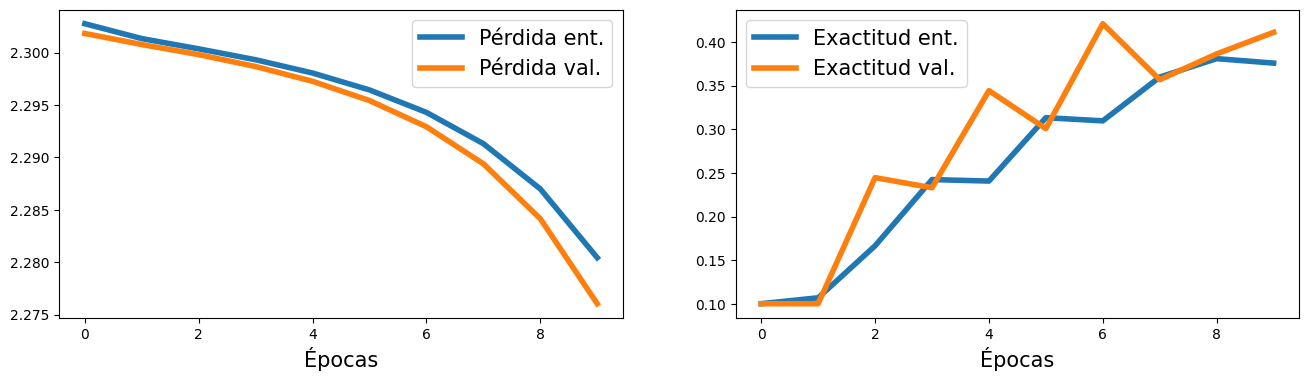

In [259]:
fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(historico[0], lw=4)
plt.plot(historico[1], lw=4)
plt.legend(['Pérdida ent.', 'Pérdida val.'], fontsize=15)
ax.set_xlabel('Épocas', size=15)
ax = fig.add_subplot(1, 2, 2)
plt.plot(historico[2], lw=4)
plt.plot(historico[3], lw=4)
plt.legend(['Exactitud ent.', 'Exactitud val.'], fontsize=15)
ax.set_xlabel('Épocas', size=15)

Como podemos ver en las gráficas, al aumentar el número de epocas disminuye la pérdida en entrenamiento y validación y aumenta la exactitud.

**Apartado f**

In [260]:
entrada = X_val[:5]  # Tomamos las primeras 5 muestras
entrada = entrada.view(-1, 1, 28, 28)  # Añadimos canal para que coincida con input esperado

with torch.no_grad():
    potenciales = modelo(entrada)  # Salida del modelo (potenciales)

# Aplicamos Softmax para obtener las probabilidades
probabilidades = nn.functional.softmax(potenciales, dim=1)

# Mostrar la clase predicha (la clase con mayor probabilidad) y las probabilidades asociadas
for i, prob in enumerate(probabilidades):
    clase_predicha = prob.argmax().item()  # Clase predicha
    probabilidades_redondeadas = [round(p.item(), 4) for p in prob]  # Redondear probabilidades a 4 decimales
    print(f"Muestra {i}: \nClase predicha = {clase_predicha}")
    print(f"Clase deseada = {y_val[i].item()}")
    print(f"Probabilidades: {probabilidades_redondeadas}")
    print("-" * 100)

Muestra 0: 
Clase predicha = 7
Clase deseada = 9
Probabilidades: [0.0976, 0.0968, 0.0992, 0.098, 0.0962, 0.1036, 0.098, 0.1052, 0.1011, 0.1043]
----------------------------------------------------------------------------------------------------
Muestra 1: 
Clase predicha = 4
Clase deseada = 2
Probabilidades: [0.1022, 0.1013, 0.102, 0.101, 0.1042, 0.095, 0.1026, 0.0939, 0.0995, 0.0983]
----------------------------------------------------------------------------------------------------
Muestra 2: 
Clase predicha = 1
Clase deseada = 1
Probabilidades: [0.1026, 0.104, 0.1019, 0.1031, 0.1031, 0.0951, 0.1015, 0.0941, 0.0976, 0.097]
----------------------------------------------------------------------------------------------------
Muestra 3: 
Clase predicha = 1
Clase deseada = 1
Probabilidades: [0.1017, 0.1029, 0.1014, 0.1025, 0.1016, 0.0969, 0.1007, 0.0962, 0.098, 0.0981]
----------------------------------------------------------------------------------------------------
Muestra 4: 
Clase pr

**Apartado g**

En la muestra 3, ya que es la que menor diferencia tiene entre las probabilidades a pertenecer a cada clase. En este caso, aunque la clase predicha coincida con la clase deseada, la probabilidad de pertenecer a la clase 1 tiene muy poca diferencia con la probabilidad de pertenecer a la clase 3.

#EJERCICIO 3

**Apartado a**

In [263]:
# Definimos los porcentajes de los subconjuntos
porcentajes = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# Listas para almacenar las métricas de entrenamiento y validación para cada MLP
loss_hist_ent_mlps = []
exact_hist_ent_mlps = []
loss_hist_val_mlps = []
exact_hist_val_mlps = []

In [264]:
num_epocas = 10

for i, porcentaje in enumerate(porcentajes):
    print(f"\nEntrenando MLP con el {int(porcentaje*100)}% del conjunto de entrenamiento...")

    # Crear el subconjunto del conjunto de entrenamiento
    num_muestras_subconjunto = int(len(ent_dataset) * porcentaje)
    indices_subconjunto = torch.randperm(len(ent_dataset))[:num_muestras_subconjunto]
    ent_subconjunto = torch.utils.data.Subset(ent_dataset, indices_subconjunto)

    # Crear el DataLoader para el subconjunto
    tam_lote = 64
    ent_loader_subconjunto = DataLoader(ent_subconjunto, tam_lote, shuffle=True)

    # Reinicializar el modelo para cada entrenamiento
    torch.manual_seed(10 + i) # Cambiamos la semilla para cada modelo
    modelo_mlp = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 128),
        nn.Sigmoid(),
        nn.Linear(128, 64),
        nn.Sigmoid(),
        nn.Linear(64, 10),
        nn.Sigmoid()
    )

    # Definición de la función de pérdida y optimizador
    loss_fn = nn.CrossEntropyLoss()
    optimizador = torch.optim.SGD(modelo_mlp.parameters(), lr=0.01)

    # Normalizamos las imágenes de validación una sola vez
    X_val = val_dataset.data.float() / 255.
    y_val = val_dataset.targets

    # Entrenar el modelo con el subconjunto actual
    historico_mlp = entrenar(modelo_mlp, num_epocas, ent_loader_subconjunto, X_val, y_val,
                             loss_fn, optimizador, True)

    # Almacenar las métricas de la última época
    loss_hist_ent_mlps.append(historico_mlp[0][-1])
    exact_hist_ent_mlps.append(historico_mlp[2][-1])
    loss_hist_val_mlps.append(historico_mlp[1][-1])
    exact_hist_val_mlps.append(historico_mlp[3][-1])


Entrenando MLP con el 10% del conjunto de entrenamiento...
Época 10/10 | Pérdida Entrenamiento: 2.3016 | Pérdida Validación: 2.3021 | Exactitud Entrenamiento: 0.1017 | Exactitud Validación: 0.1000

Entrenando MLP con el 20% del conjunto de entrenamiento...
Época 10/10 | Pérdida Entrenamiento: 2.3010 | Pérdida Validación: 2.3013 | Exactitud Entrenamiento: 0.1036 | Exactitud Validación: 0.1000

Entrenando MLP con el 30% del conjunto de entrenamiento...
Época 10/10 | Pérdida Entrenamiento: 2.3002 | Pérdida Validación: 2.3002 | Exactitud Entrenamiento: 0.1607 | Exactitud Validación: 0.1776

Entrenando MLP con el 40% del conjunto de entrenamiento...
Época 10/10 | Pérdida Entrenamiento: 2.2993 | Pérdida Validación: 2.2992 | Exactitud Entrenamiento: 0.1925 | Exactitud Validación: 0.1268

Entrenando MLP con el 50% del conjunto de entrenamiento...
Época 10/10 | Pérdida Entrenamiento: 2.2983 | Pérdida Validación: 2.2981 | Exactitud Entrenamiento: 0.1081 | Exactitud Validación: 0.1000

Entrenand

**Apartado b**

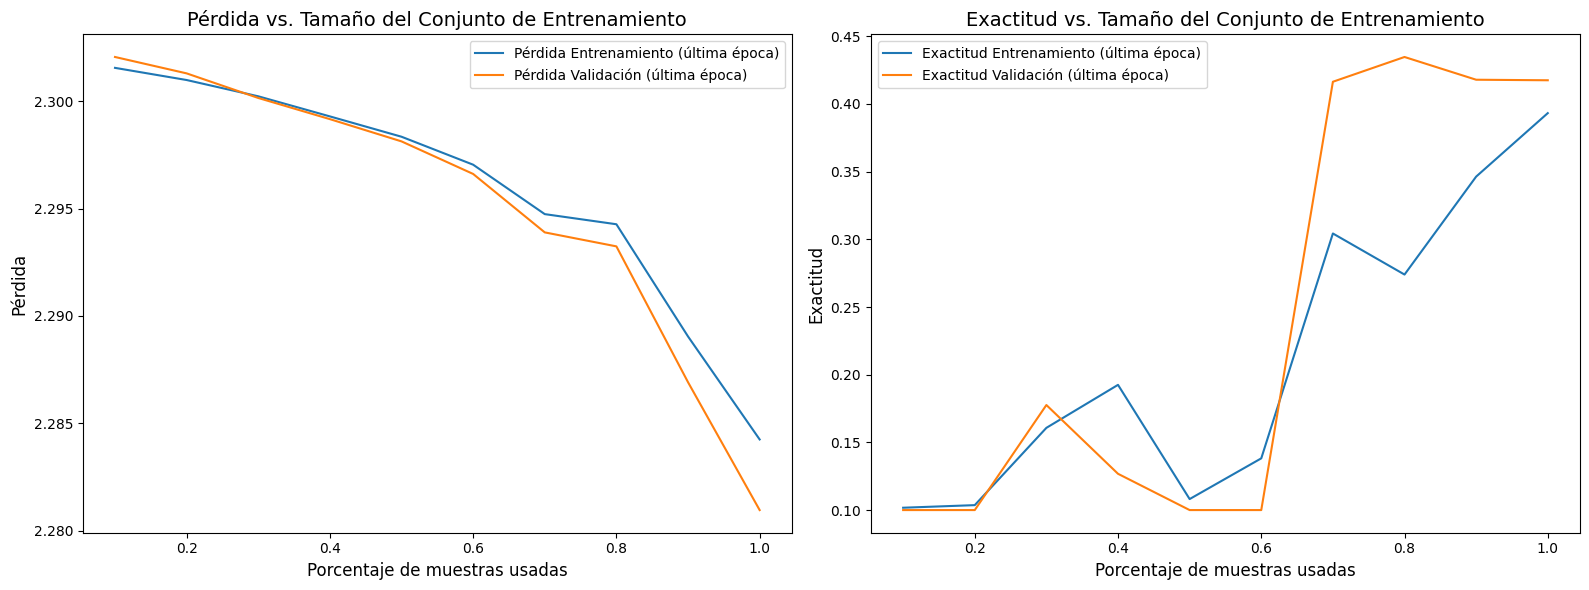

In [270]:
# Graficar el rendimiento en función del tamaño del conjunto de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de Pérdida
axes[0].plot(porcentajes, loss_hist_ent_mlps, linestyle='-', label='Pérdida Entrenamiento (última época)')
axes[0].plot(porcentajes, loss_hist_val_mlps, linestyle='-', label='Pérdida Validación (última época)')
axes[0].set_xlabel('Porcentaje de muestras usadas', size=12)
axes[0].set_ylabel('Pérdida', size=12)
axes[0].set_title('Pérdida vs. Tamaño del Conjunto de Entrenamiento', size=14)
axes[0].legend()

# Gráfico de Exactitud
axes[1].plot(porcentajes, exact_hist_ent_mlps, linestyle='-', label='Exactitud Entrenamiento (última época)')
axes[1].plot(porcentajes, exact_hist_val_mlps, linestyle='-', label='Exactitud Validación (última época)')
axes[1].set_xlabel('Porcentaje de muestras usadas', size=12)
axes[1].set_ylabel('Exactitud', size=12)
axes[1].set_title('Exactitud vs. Tamaño del Conjunto de Entrenamiento', size=14)
axes[1].legend()

plt.tight_layout()
plt.show()

Podemos ver en las gráficas como al aumentar el el porcentaeje de muestras en entrenamiento la pérdida disminuye, mientras que la exactitud aumenta considerable a partir de un 60%-70% que es lo que se suele tomar de entrenamiento normalmente.